In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
!pip freeze > requirements.txt

In [76]:
BASE_PATH = '../dataset'
MODELS = os.path.join(BASE_PATH, 'models')
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
DATASET = os.path.join(BASE_PATH, 'dataset_produksi_padi.csv')

os.makedirs(os.path.join(MODELS, 'k-fold'), exist_ok=True)

In [60]:
df = pd.read_csv(DATASET)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2529 entries, 0 to 2528
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2529 non-null   object 
 1   luas_panen          2529 non-null   float64
 2   produktivitas       2529 non-null   float64
 3   produksi            2529 non-null   float64
 4   tahun               2529 non-null   int64  
 5   curah_hujan_rataan  2529 non-null   float64
 6   curah_hujan_total   2529 non-null   float64
 7   suhu_rataan         2529 non-null   float64
 8   suhu_maksimum       2529 non-null   float64
 9   suhu_minimum        2529 non-null   float64
 10  kelembapan_rataan   2529 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 217.5+ KB


In [62]:
X = df.drop(columns=['kabupaten', 'produksi', 'produktivitas'])
y = df['produksi']

In [66]:
X_arr = X.to_numpy()
y_arr = y.to_numpy()

# 2. Inisialisasi K-Fold (Misal 10 Lipatan)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scaler = StandardScaler()
model_lr = LinearRegression()

# List untuk menampung skor dari setiap lipatan (fold)
mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

# Variabel untuk menampung prediksi keseluruhan data
y_all_true = []
y_all_pred = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr), 1):
    # Memisahkan data train dan data validasi pada fold saat ini
    X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
    y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
    
    # Normalisasi Fitur
    X_train_f_scaled = scaler.fit_transform(X_train_f)
    X_val_f_scaled = scaler.transform(X_val_f)
    
    # Training Model
    model_lr.fit(X_train_f_scaled, y_train_f)
    
    # Prediksi
    y_pred_f = model_lr.predict(X_val_f_scaled)
    
    # Hitung metrik pada fold saat ini
    f_mae = mean_absolute_error(y_val_f, y_pred_f)
    f_mse = mean_squared_error(y_val_f, y_pred_f)
    f_rmse = np.sqrt(f_mse)
    f_r2 = r2_score(y_val_f, y_pred_f)
    
    # Simpan hasil per fold
    mae_scores.append(f_mae)
    mse_scores.append(f_mse)
    rmse_scores.append(f_rmse)
    r2_scores.append(f_r2)
    
    # Simpan nilai asli vs prediksi untuk visualisasi akhir
    y_all_true.extend(y_val_f)
    y_all_pred.extend(y_pred_f)
    
    print(f"Fold {fold} -> MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

Fold 1 -> MAE: 16426.22 | RMSE: 26495.92 | R2: 0.9827
Fold 2 -> MAE: 18343.51 | RMSE: 30493.33 | R2: 0.9803
Fold 3 -> MAE: 18824.14 | RMSE: 32710.39 | R2: 0.9760
Fold 4 -> MAE: 18561.30 | RMSE: 30329.88 | R2: 0.9818
Fold 5 -> MAE: 18021.21 | RMSE: 28985.66 | R2: 0.9782
Fold 6 -> MAE: 20271.16 | RMSE: 34291.51 | R2: 0.9767
Fold 7 -> MAE: 19834.71 | RMSE: 35892.69 | R2: 0.9777
Fold 8 -> MAE: 17919.63 | RMSE: 30421.72 | R2: 0.9831
Fold 9 -> MAE: 16949.13 | RMSE: 27003.09 | R2: 0.9768
Fold 10 -> MAE: 20405.14 | RMSE: 37608.43 | R2: 0.9718


In [ ]:
print("=== RATA-RATA EVALUASI K-FOLD MODEL LINEAR REGRESSION ===")
print(f"Rata-rata MAE  : {np.mean(mae_scores):.2f}")    
print(f"Rata-rata RMSE : {np.mean(rmse_scores):.2f}")
print(f"Rata-rata R2   : {np.mean(r2_scores):.4f} (atau {np.mean(r2_scores)*100:.1f}%)")

=== RATA-RATA EVALUASI K-FOLD MODEL LINEAR REGRESSION ===
Rata-rata MAE  : 18555.61
Rata-rata RMSE : 31423.26
Rata-rata R2   : 0.9785 (atau 97.9%)


In [78]:
joblib.dump(model_lr, os.path.join(MODELS,'k-fold/model_k_fold_linear_regression_final.joblib'))
joblib.dump(scaler, os.path.join(MODELS,'k-fold/scaler_k_fold_final.joblib'))

print("Model Final dan Scaler berhasil disimpan dalam format .joblib!")

Model Final dan Scaler berhasil disimpan dalam format .joblib!


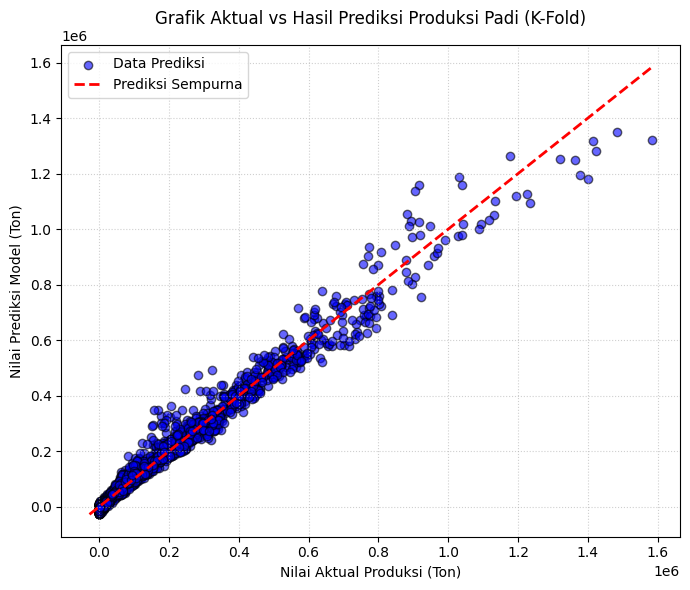

In [79]:
# Plot Nilai Aktual vs Hasil Prediksi Model
plt.figure(figsize=(7, 6))
plt.scatter(y_all_true, y_all_pred, color='blue', alpha=0.6, edgecolors='k', label='Data Prediksi')

# Garis diagonal bantu linearitas sempurna
max_val = max(max(y_all_true), max(y_all_pred))
min_val = min(min(y_all_true), min(y_all_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prediksi Sempurna')

plt.title('Grafik Aktual vs Hasil Prediksi Produksi Padi (K-Fold)', fontsize=12, pad=15)
plt.xlabel('Nilai Aktual Produksi (Ton)', fontsize=10)
plt.ylabel('Nilai Prediksi Model (Ton)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'k-fold/matriks_korelasi_final.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

In [83]:
threshold = np.mean(y_all_true)

# 2. Konversi nilai aktual dan prediksi kontinu menjadi kategori biner (0 atau 1)
# 0 = Produksi Di Bawah Rata-rata (Rendah)
# 1 = Produksi Di Atas/Sama Dengan Rata-rata (Tinggi)
y_true_classified = np.where(np.array(y_all_true) >= threshold, 1, 0)
y_pred_classified = np.where(np.array(y_all_pred) >= threshold, 1, 0)

cm = confusion_matrix(y_true_classified, y_pred_classified)
accuracy = accuracy_score(y_true_classified, y_pred_classified)

print("=== EVALUASI KATEGORIKAL ===")
print(f"Ambang Batas Produksi Rata-rata: {threshold:.2f} Ton\n")
print(f"Akurasi Kategorikal: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true_classified, y_pred_classified, 
                            target_names=['Produksi Rendah', 'Produksi Tinggi']))

=== EVALUASI KATEGORIKAL ===
Ambang Batas Produksi Rata-rata: 154258.67 Ton

Akurasi Kategorikal: 97.94%

Classification Report:
                 precision    recall  f1-score   support

Produksi Rendah       0.99      0.98      0.98      1694
Produksi Tinggi       0.95      0.98      0.97       835

       accuracy                           0.98      2529
      macro avg       0.97      0.98      0.98      2529
   weighted avg       0.98      0.98      0.98      2529



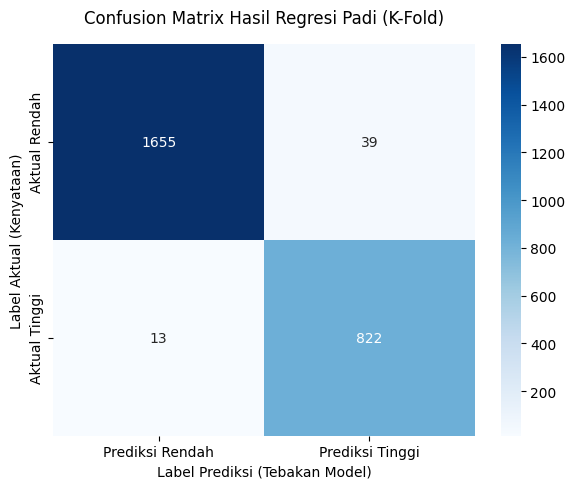

In [80]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Prediksi Rendah', 'Prediksi Tinggi'],
    yticklabels=['Aktual Rendah', 'Aktual Tinggi']
)

plt.title('Confusion Matrix Hasil Regresi Padi (K-Fold)', fontsize=12, pad=15)
plt.ylabel('Label Aktual (Kenyataan)', fontsize=10)
plt.xlabel('Label Prediksi (Tebakan Model)', fontsize=10)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'k-fold/confusion_matrix_final.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()